# Directional consensus (DC) on long legal definitions — demo

This notebook demos the experiment **"Peer-agreement metric on long legal definitions"**. The experiment is a secondary transfer test of the
**directional consensus (DC)** metric for NL→FOL faithfulness. It runs panel-only (no gold formulas) on 158 long legal sentences:
AI-Act Art. 3 definitions, GDPR/DSA/DMA/Data Act and SARA-IRC tax rules.

**What DC measures.** DC takes a sentence and a candidate FOL formula, together with the *other systems' formalizations of the same sentence*
(the peers). For each peer, a z3-backed search finds a **lexical-free, arity-preserving vocabulary alignment** under which the two formulas can be
compared. Predicate names are never read as words. The search then decides the logical order between the pair: EQUIV / STRONGER / WEAKER /
COMPATIBLE-INCOMPARABLE / CONTRADICTORY / UNALIGNABLE / UNKNOWN.
The DC score is the reliability-weighted share of peers that are logically **equivalent** to the candidate. It uses no gold formula and no ontology,
and the text itself is never read.

**Full-run results (for reference).**
- 9 OpenRouter systems plus 367 pilot formulas produced 655 candidates, each labelled by a calibrated 3-model panel.
- X1: AUROC(DC) = 0.705 [0.608, 0.792].
- The cheap LLM judge B1 dominates at 0.927.
- DC adds only a marginal +0.021 over [B1, parse].

**What this notebook does.**
1. It writes the original `dc/` package and its vendored helpers to disk, verbatim, from the data file, then runs `method.py`'s code: the stage list and the toy `demo()`.
2. It **re-computes DC live** with the z3 solver on real legal sentences from the curated subset, and checks the scores against the frozen full-run scores.
3. It evaluates DC and the baselines against the panel labels on the curated 100-candidate subset, using weighted AUROC, sentence-bootstrap CIs, marker-bin breakdowns and coverage.

The full pipeline (`method.py --stages all`) calls paid OpenRouter models and a local GPU model, so it is **listed but not executed** here.
Its outputs (frozen metric scores) are part of the demo data.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import subprocess
import sys
from pathlib import Path

# --- additional imports for the notebook (data loading, evaluation, plots) ---
import json
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-2/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            remote = json.loads(response.read().decode())
        if "source_files" in remote and "sentences" in remote:  # guard against a stale file at the same URL
            return remote
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['sentences'])} sentences, {len(data['examples'])} panel-labelled candidates, "
      f"{sum(len(s['pool']) for s in data['sentences'].values())} peer-pool formulas, "
      f"{len(data['source_files'])} bundled source files: {list(data['source_files'])}")

Curated subset of the DC legal-transfer experiment (panel-labelled candidates) + DC source code
21 sentences, 100 panel-labelled candidates, 236 peer-pool formulas, 7 bundled source files: ['method.py', 'dc/__init__.py', 'dc/api.py', 'dc/core.py', 'vendor/ds/fol_parse.py', 'vendor/ds/fol_equiv.py', 'vendor/armB/latent_class.py']


## Config

These are all the tunable parameters. The defaults below are sized to finish well inside a 10-minute budget. The frozen contract-v1 values used in the full run are noted in each comment.

- `N_LIVE_SENTENCES` is the number of curated sentences whose candidates are **re-scored live** with the z3 solver. There are at most 21 in the mini data, and the full run scored 158.
- `PAIR_SECONDS` and `DOMAINS` are the per-pair solver budget and the finite domain sizes for the grounding check. Lowering them can turn some pairs into UNKNOWN.
- `N_BOOT` is the number of sentence-level bootstrap draws for the AUROC confidence intervals.

In [5]:
N_LIVE_SENTENCES = 21        # sentences re-scored live with DC (mini data holds 21; full run: all 158)
PAIR_SECONDS = 20.0          # per-pair wall-clock cap (frozen contract v1: 20.0)
DOMAINS = [1, 2, 3, 4]       # grounding domain sizes for the bounded z3 check (frozen: [1, 2, 3, 4])
N_BOOT = 2000                # sentence-bootstrap draws for AUROC CIs (full run: 2000)
BOOT_SEED = 0                # bootstrap seed (full run: 0)
METRICS = ["DC", "DC_noL3", "DC_fp", "DC_unw", "LC_maj", "VC", "B1", "B1plus", "B3nli", "B3cos", "B7", "B2", "DC_placebo"]

## 1. Materialise the original code and run `method.py`'s import block

The artifact's `method.py` is a thin entry point. The metric itself lives in the `dc/` package, contract v1:
- `dc/core.py` holds the alignment search and the z3 checks;
- `dc/api.py` holds `directional_consensus`, `error_type` and `ds_weights`.

These modules build on vendored helpers: `fol_parse` (parser), `fol_equiv` (bounded z3 grounding) and `latent_class` (Dawid–Skene EM).
The data file carries these sources **unchanged**, so the next cell writes them into a local folder that mirrors the artifact layout (`dc/`, `vendor/ds/`, `vendor/armB/`).

The only change from `method.py` is `ROOT`. It pointed at `Path(__file__).parent`, and in the notebook it points at this folder.

In [6]:
ROOT = Path("dc_demo_src").resolve()      # original: ROOT = Path(__file__).resolve().parent
for rel, txt in data["source_files"].items():
    p = ROOT / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(txt, encoding="utf-8")

# --- from here on: method.py, verbatim ---
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

from dc.api import align_pair, directional_consensus, ds_weights, error_type, pair_relation, score_from_relations  # noqa: E402,F401
from dc.core import Formula  # noqa: E402,F401

## 2. The pipeline stage list (reference only — not executed)

`method.py --stages all` runs these resumable stages as subprocesses under `src/`:
- **sentences** builds the 158-sentence legal set.
- **generate** gets 9 systems' greedy outputs plus 2×5 samples.
- **l1** and **panel** run the no-gold 3-model panel labelling.
- **dc** computes all pair relations and freezes the scores *before any label is read*.
- **baselines** covers B1 (LLM judge), B3 (back-translation), and B7/VC (structural and self-consistency).
- **extra** runs invariance, the shuffled-peer placebo and the dev anchor.
- **analysis** and **export** produce the reported tests.

These stages need OpenRouter API keys, a GPU and the `src/` scripts, none of which are in this demo, so the list is only defined here. Their frozen outputs are in `data["examples"]`.

In [7]:
PY = str(ROOT / ".venv" / "bin" / "python")
STAGES = [
    ("sentences", [["build_sentences.py"]]),
    ("generate", [["generate_long.py", "--probe", "20"], ["generate_long.py", "--full"], ["generate_long.py", "--assemble"]]),
    ("l1", [["panel_nogold.py", "l1"]]),
    ("panel", [["panel_nogold.py", "smoke"], ["panel_nogold.py", "calibrate"], ["panel_nogold.py", "sample"],
               ["panel_nogold.py", "run", "--pilot-cost"], ["panel_nogold.py", "run"]]),
    ("dc", [["run_dc.py", "--set", "legal", "--limit", "10"], ["run_dc.py", "--set", "legal"],
            ["run_dc.py", "--set", "legal", "--order", "fp", "--workers", "5"], ["dc_score.py", "--set", "legal", "--freeze"]]),
    ("baselines", [["baselines.py", "b1"], ["baselines.py", "b1plus"], ["baselines.py", "b3"], ["local_judge.py", "b3"],
                   ["baselines.py", "struct"], ["local_judge.py", "arb"]]),
    ("extra", [["dev_anchor.py", "frame"], ["dev_anchor.py", "l1"], ["run_dc.py", "--set", "dev", "--workers", "5", "--budget", "120"],
               ["dc_score.py", "--set", "dev"], ["dev_anchor.py", "auroc"], ["extra_dc.py", "invariance"], ["extra_dc.py", "placebo"],
               ["crossimpl.py"], ["alignment_audit.py"]]),
    ("analysis", [["deviations.py"], ["analysis.py"]]),
    ("export", [["export.py"]]),
]
for name, cmds in STAGES:
    print(f"{name:10s} " + " | ".join(" ".join(c) for c in cmds))

sentences  build_sentences.py
generate   generate_long.py --probe 20 | generate_long.py --full | generate_long.py --assemble
l1         panel_nogold.py l1
panel      panel_nogold.py smoke | panel_nogold.py calibrate | panel_nogold.py sample | panel_nogold.py run --pilot-cost | panel_nogold.py run
dc         run_dc.py --set legal --limit 10 | run_dc.py --set legal | run_dc.py --set legal --order fp --workers 5 | dc_score.py --set legal --freeze
baselines  baselines.py b1 | baselines.py b1plus | baselines.py b3 | local_judge.py b3 | baselines.py struct | local_judge.py arb
extra      dev_anchor.py frame | dev_anchor.py l1 | run_dc.py --set dev --workers 5 --budget 120 | dc_score.py --set dev | dev_anchor.py auroc | extra_dc.py invariance | extra_dc.py placebo | crossimpl.py | alignment_audit.py
analysis   deviations.py | analysis.py
export     export.py


## 3. `method.py`'s toy demo: one legal definition against three peers

`demo()` scores a candidate formalization of the AI-Act definition of *provider* against three peers:
- **peer 1** is the *same* formula with every predicate and variable renamed. DC must still find it EQUIV, because names are never read.
- **peer 2** drops the exception "other than a public authority" (`¬PublicAuthority`). Under a biconditional, dropping a conjunct makes the definition
  *more* permissive in one direction and *less* in the other. So the two formulas are **COMPATIBLE-INCOMPARABLE**, not simply STRONGER. `PublicAuthority` has no
  counterpart in peer 2, so the pair is decided at L2, a partial map.
- **peer 3** weakens the biconditional `↔` to an implication `→`, which gives STRONGER: the candidate entails peer 3.

The score is the share of EQUIV peers, 1 of 3 here. `level` is the alignment level that decided the pair: L1 bijection, L2 partial map or L3 granularity definitions.
`main()` is copied unchanged. Its argparse reads `sys.argv`, so the notebook sets it to `--demo` first; that is the only change.

In [8]:
def demo() -> None:
    text = "'provider' means a natural or legal person, other than a public authority, that places an AI system on the market."
    cand = "∀x (Provider(x) ↔ ((NaturalPerson(x) ∨ LegalPerson(x)) ∧ ¬PublicAuthority(x) ∧ ∃y (AISystem(y) ∧ PlacesOnMarket(x, y))))"
    peers = ["∀p (Prov(p) ↔ ((Natural(p) ∨ Legal(p)) ∧ ¬PubAuth(p) ∧ ∃s (AISys(s) ∧ Places(p, s))))",
             "∀x (Provider(x) ↔ ((NaturalPerson(x) ∨ LegalPerson(x)) ∧ ∃y (AISystem(y) ∧ PlacesOnMarket(x, y))))",
             "∀x (Provider(x) → ((NaturalPerson(x) ∨ LegalPerson(x)) ∧ ¬PublicAuthority(x) ∧ ∃y (AISystem(y) ∧ PlacesOnMarket(x, y))))"]
    r = directional_consensus(text, cand, peers)
    print({k: r[k] for k in ("score", "coverage", "n_covered", "strength_profile", "relation_counts")})
    for p in peers:
        rel = pair_relation(cand, p)
        print(rel["relation"], "level", rel.get("level"), "map", rel.get("map"))


def main() -> None:
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--stages", default="", help="comma list of stage names or 'all'")
    ap.add_argument("--demo", action="store_true", help="score a toy legal definition against 3 peers (no API)")
    a = ap.parse_args()
    if a.demo or not a.stages:
        demo()
        return
    names = [s for s, _ in STAGES] if a.stages == "all" else a.stages.split(",")
    for name, cmds in STAGES:
        if name not in names:
            continue
        for cmd in cmds:
            print(f"=== {name}: {' '.join(cmd)}", flush=True)
            r = subprocess.run([PY, *cmd], cwd=ROOT / "src")
            if r.returncode != 0:
                raise RuntimeError(f"stage {name} step {cmd} failed ({r.returncode})")


__doc__ = "Directional consensus (DC) on long, exception-heavy legal definitions — reusable API + full pipeline."
sys.argv = ["method.py", "--demo"]   # notebook: replaces the command line (Jupyter's own argv would break argparse)
t0 = time.time()
main()
print(f"demo took {time.time() - t0:.1f}s")

{'score': 0.3333333333333333, 'coverage': 1, 'n_covered': 3, 'strength_profile': 0.3333333333333333, 'relation_counts': {'EQUIV': 1, 'COMPATIBLE-INCOMPARABLE': 1, 'STRONGER': 1}}
EQUIV level 1 map {'Prov': 'Provider', 'Natural': 'NaturalPerson', 'Legal': 'LegalPerson', 'PubAuth': 'PublicAuthority', 'AISys': 'AISystem', 'Places': 'PlacesOnMarket'}
COMPATIBLE-INCOMPARABLE level 2 map {'Provider': 'Provider', 'NaturalPerson': 'NaturalPerson', 'LegalPerson': 'LegalPerson', 'AISystem': 'AISystem', 'PlacesOnMarket': 'PlacesOnMarket'}


STRONGER level 1 map {'Provider': 'Provider', 'NaturalPerson': 'NaturalPerson', 'LegalPerson': 'LegalPerson', 'PublicAuthority': 'PublicAuthority', 'AISystem': 'AISystem', 'PlacesOnMarket': 'PlacesOnMarket'}
demo took 0.7s


The rule-based **error typing** (`error_type`) names the difference between a candidate and a reference formula. In the pipeline, the reference is the modal
peer cluster. The next cell applies it to the toy demo, taking each peer in turn as the reference.

The rules only fire for specific relation shapes. For example, *added/dropped condition* needs STRONGER or WEAKER plus a predicate present on one side only.
Peer 2's dropped exception therefore gets `other`, because its relation is INCOMPARABLE. Peer 3's `↔`→`→` weakening shares all predicates, so it falls through to the
`argument_swap` slot rule.

This is a real limitation, and it matches the reported negative result: DC error naming fails on the legal set, with top-1 agreement with the panel's error type of 0.044.
The `exception_involved` flag marks a differing literal negated inside an antecedent, the formula shape of "unless" and "except".

In [9]:
cand = "∀x (Provider(x) ↔ ((NaturalPerson(x) ∨ LegalPerson(x)) ∧ ¬PublicAuthority(x) ∧ ∃y (AISystem(y) ∧ PlacesOnMarket(x, y))))"
toy_peers = ["∀p (Prov(p) ↔ ((Natural(p) ∨ Legal(p)) ∧ ¬PubAuth(p) ∧ ∃s (AISys(s) ∧ Places(p, s))))",
             "∀x (Provider(x) ↔ ((NaturalPerson(x) ∨ LegalPerson(x)) ∧ ∃y (AISystem(y) ∧ PlacesOnMarket(x, y))))",
             "∀x (Provider(x) → ((NaturalPerson(x) ∨ LegalPerson(x)) ∧ ¬PublicAuthority(x) ∧ ∃y (AISystem(y) ∧ PlacesOnMarket(x, y))))"]
C = Formula(cand)
for k, p in enumerate(toy_peers, 1):
    M = Formula(p)
    rel = pair_relation(C, M)                  # A = candidate, B = reference peer
    et, exc = error_type(C, M, rel, True)      # c_is_a=True: the candidate is side A
    print(f"peer {k}: relation={rel['relation']:<24s} error_type={et:<18s} exception_involved={exc}")

peer 1: relation=EQUIV                    error_type=none               exception_involved=False
peer 2: relation=COMPATIBLE-INCOMPARABLE  error_type=other              exception_involved=False
peer 3: relation=STRONGER                 error_type=argument_swap      exception_involved=False


## 4. Live DC on real legal sentences (z3 solver, contract v1)

For each curated sentence, the next cell rebuilds the **exact peer rule** of the frozen run (`src/dc_score.py`):
- **System candidates** are compared with the other 8 systems' greedy outputs plus the pilot formulas. The pilot family counts as one rater, so its weight is split equally over its parseable runs.
- **Pilot candidates** are compared with the 9 systems' greedy outputs.
- **Weights** are the frozen one-coin Dawid–Skene weights. They all collapsed to the 0.05 floor, a reported finding: equivalence agreement is too rare on long legal text for DS to separate systems.

Each candidate then goes through `directional_consensus(text, fol, peers, weights, limits=...)`. An unparseable candidate, or one with fewer than 2 covered peers, gets
the contract's 0.5 with coverage 0. Such items are **counted, never dropped**.

The live scores are compared with the frozen `DC` column, and they should agree exactly under the frozen limits: 5 s per z3 call and a 20 s wall-clock cap per pair.
On a much slower machine, an occasional pair can hit the cap and become UNKNOWN, which shifts that candidate's score slightly.

There is one known source of rare mismatches. The frozen pipeline (`src/run_dc.py`) computed each *unordered* pair once, in sorted canonical-string order, and inverted the relation when needed.
The L2 alignment rule is **directional**: it needs a map covering at least 50% of *B*'s predicate occurrences. So a pair can be UNALIGNABLE when the candidate is side A and still alignable the other way round.
`directional_consensus` always puts the candidate on side A. On the 21 curated sentences, 99 of 100 candidates reproduce exactly. The exception is `b1532a08c0:gemini-2.5-flash:0`: live it has fewer than 2 covered peers, giving 0.5 with coverage 0, while the frozen score is 0.0.

In [10]:
W = data["ds_weights"]
LIMITS = {**data["limits"], "pair_seconds": PAIR_SECONDS, "domains": DOMAINS}
ex_by_sid = defaultdict(list)
for e in data["examples"]:
    ex_by_sid[e["sentence_id"]].append(e)
# cheapest sentences first (smallest peer pool, fewest labelled candidates) so small N_LIVE_SENTENCES stays fast
live_sids = sorted(data["sentences"], key=lambda s: (len(data["sentences"][s]["pool"]), len(ex_by_sid[s]), s))[:N_LIVE_SENTENCES]

live_rows = []
t_live = time.time()
for sid in live_sids:
    S = data["sentences"][sid]
    pool = {c["cand_id"]: c for c in S["pool"]}
    greedy = [c for c in S["pool"] if c["frame"] == "system"]
    pil_ok = [c for c in S["pool"] if c["frame"] == "pilot" and c["parse_ok"]]
    wp = W.get("pilot", 1.0)

    def peers_of(c):  # same rule as src/dc_score.py
        if c["frame"] == "pilot":
            return [(g, W.get(g["system"], 1.0)) for g in greedy if g["parse_ok"]]
        ps = [(g, W.get(g["system"], 1.0)) for g in greedy if g["system"] != c["system"] and g["parse_ok"]]
        ps += [(p, wp / len(pil_ok)) for p in pil_ok]
        return ps

    t_s = time.time()
    for e in ex_by_sid[sid]:
        c = pool[e["cand_id"]]
        ps = peers_of(c)
        r = directional_consensus(S["text"], c["fol"], [p["fol"] for p, _ in ps], [w for _, w in ps], limits=LIMITS)
        live_rows.append({"sentence_id": sid, "bin": S["marker_bin"], "cand_id": e["cand_id"], "label": e["label"],
                          "DC_live": r["score"], "DC_frozen": e["DC"], "coverage": r["coverage"],
                          "n_peers": len(ps), "n_covered": r["n_covered"], "strength": round(r["strength_profile"], 3),
                          "relations": dict(r.get("relation_counts") or {}), "reason": r.get("reason", "")})
    print(f"{sid} [{S['marker_bin']}, {S['n_tokens']} tok, pool {len(S['pool'])}]: "
          f"{len(ex_by_sid[sid])} candidates in {time.time() - t_s:.1f}s")

live = pd.DataFrame(live_rows)
live["match"] = (live["DC_live"] - live["DC_frozen"]).abs() < 1e-6
print(f"\nlive DC: {len(live)} candidates from {len(live_sids)} sentences in {time.time() - t_live:.1f}s; "
      f"agreement with frozen scores: {live['match'].sum()}/{len(live)}; "
      f"coverage-0 items (score 0.5, kept): {(live['coverage'] == 0).sum()}")

7ed5017eed [B0, 36 tok, pool 9]: 2 candidates in 0.7s
886019d743 [B2, 125 tok, pool 9]: 2 candidates in 0.0s


f82eba2ce1 [B1, 50 tok, pool 9]: 2 candidates in 2.4s


238b6ee9cd [B0, 39 tok, pool 9]: 3 candidates in 0.7s


529b554678 [B2, 78 tok, pool 9]: 3 candidates in 4.1s


c8612f3339 [B0, 20 tok, pool 9]: 3 candidates in 0.5s


...

25b45a6e1d [B0, 25 tok, pool 15]: 6 candidates in 7.0s


a74b35c0cb [B0, 23 tok, pool 15]: 6 candidates in 3.9s


fc6dad52e3 [B0, 34 tok, pool 15]: 6 candidates in 5.2s


251b4d69af [B0, 15 tok, pool 15]: 9 candidates in 5.8s


feca780c31 [B2, 171 tok, pool 15]: 10 candidates in 37.9s

live DC: 100 candidates from 21 sentences in 112.2s; agreement with frozen scores: 99/100; coverage-0 items (score 0.5, kept): 14


The first sentence of the curated set is shown in full below. The table lists how each candidate relates to its peers: `relations` counts how many
peers each candidate is EQUIV to, STRONGER than, and so on. On long legal text, most pairs come out **COMPATIBLE-INCOMPARABLE**. This matches the reported
finding that EQUIV agreement is rare, 6% of legal pairs against 19% on short text. It is why DC is often 0 even for faithful candidates.

In [11]:
first = live_sids[0]
print("SENTENCE:", data["sentences"][first]["text"][:600], "\n")
for e in ex_by_sid[first][:3]:
    print(f"[{e['label']:10s}] {e['system']:>22s}: {e['candidate_fol'][:300]}")
pd.set_option("display.max_colwidth", 80)
live[["sentence_id", "bin", "cand_id", "label", "DC_live", "DC_frozen", "coverage", "n_covered", "strength", "relations"]].head(20)

SENTENCE: (q) ‘active recipient of an online search engine’ means a recipient of the service that has submitted a query to an online search engine and been exposed to information indexed and presented on its online interface 

[faithful  ]       gemini-2.5-flash: ∀x (ActiveRecipient(x) ↔ (Recipient(x) ∧ SubmittedQuery(x) ∧ ExposedToInformation(x)))
[unfaithful]            gemma-3-27b: ∀x (ActiveRecipient(x) ↔ (RecipientOfService(x) ∧ SubmittedQuery(x, searchEngine) ∧ ExposedToInformation(x, searchEngine)))


,sentence_id,bin,cand_id,label,DC_live,DC_frozen,coverage,n_covered,strength,relations
0,7ed5017eed,B0,7ed5017eed:gemini-2.5-flash:0,faithful,0.000000,0.000000,1,6,0.333,"{'UNALIGNABLE': 1, 'COMPATIBLE-INCOMPARABLE': 4, 'STRONGER': 2}"
1,7ed5017eed,B0,7ed5017eed:gemma-3-27b:0,unfaithful,0.000000,0.000000,1,7,0.286,"{'COMPATIBLE-INCOMPARABLE': 5, 'STRONGER': 2}"
2,886019d743,B2,886019d743:deepseek-v3.1:0,unfaithful,0.500000,0.500000,0,0,0.000,{}
3,886019d743,B2,886019d743:gpt-oss-120b:0,faithful,0.500000,0.500000,0,0,0.000,{}
4,f82eba2ce1,B1,f82eba2ce1:gemini-2.5-flash:0,faithful,0.500000,0.500000,0,0,0.000,{}
5,f82eba2ce1,B1,f82eba2ce1:phi-4:0,unfaithful,0.000000,0.000000,1,5,-0.400,"{'WEAKER': 2, 'COMPATIBLE-INCOMPARABLE': 3}"
6,238b6ee9cd,B0,238b6ee9cd:deepseek-v3.1:0,faithful,0.625000,0.625000,1,8,0.125,"{'EQUIV': 5, 'COMPATIBLE-INCOMPARABLE': 2, 'STRONGER': 1}"
7,238b6ee9cd,B0,238b6ee9cd:gpt-4.1-mini:0,faithful,0.625000,0.625000,1,8,0.125,"{'EQUIV': 5, 'COMPATIBLE-INCOMPARABLE': 2, 'STRONGER': 1}"
8,238b6ee9cd,B0,238b6ee9cd:phi-4:0,faithful,0.625000,0.625000,1,8,0.125,"{'EQUIV': 5, 'COMPATIBLE-INCOMPARABLE': 2, 'STRONGER': 1}"
9,529b554678,B2,529b554678:mistral-small-3.2-24b:0,unfaithful,0.000000,0.000000,1,5,0.200,"{'COMPATIBLE-INCOMPARABLE': 4, 'STRONGER': 1, 'UNALIGNABLE': 1}"


## 5. Meta-evaluation on the curated subset: does DC predict panel faithfulness?

The next cell reproduces the full run's metric on the 100 panel-labelled candidates: **weighted AUROC**, with positive = *faithful* and weights = panel sampling weights,
equal to `sklearn.roc_auc_score(..., sample_weight=w)`. Missing or uncovered scores stay at 0.5, as in `src/analysis.py`. CIs come from a **sentence-level bootstrap**.

The metrics are the frozen scores computed by the full pipeline:
- **DC variants:** `DC_noL3` (no granularity alignment), `DC_fp` (alternative search order) and `DC_unw` (unweighted).
- **Peer-agreement baselines:** `LC_maj` (vendor L1 majority) and `VC` (self-consistency of samples).
- **LLM judge:** `B1` is a cheap judge and `B1plus` a stronger one (gemini-2.5-pro).
- **Back-translation:** `B3nli` and `B3cos`, using a local Qwen3-8B.
- **Structural:** `B7`, the user's pilot metrics (arity and composability).
- **Parse:** `B2`, the parse rate.
- **Placebo:** `DC_placebo` uses peers from a *different* sentence, so it should sit at about 0.5.

Caveat: the subset keeps whole sentences and is stratified by marker bin. It has 34% faithful candidates, against 10% in the full labelled set, so its AUROCs are noisier than the full-run
numbers shown alongside.

In [12]:
ex = pd.DataFrame(data["examples"])
y = (ex["label"] == "faithful").astype(int).to_numpy()
w = ex["panel_weight"].astype(float).to_numpy()
sid_arr = ex["sentence_id"].to_numpy()
uniq_sids = np.unique(sid_arr)
idx_of = {s: np.where(sid_arr == s)[0] for s in uniq_sids}

def col(m):
    return pd.to_numeric(ex[m], errors="coerce").fillna(0.5).to_numpy() if m in ex else np.full(len(ex), 0.5)

def wauc(idx, s):
    yy = y[idx]
    return roc_auc_score(yy, s[idx], sample_weight=w[idx]) if 0 < yy.sum() < len(yy) else np.nan

rng = np.random.default_rng(BOOT_SEED)
boots = [np.concatenate([idx_of[s] for s in rng.choice(uniq_sids, len(uniq_sids), replace=True)]) for _ in range(N_BOOT)]
all_idx = np.arange(len(ex))
rows = []
for m in METRICS:
    s = col(m)
    bs = np.array([wauc(b, s) for b in boots])
    rows.append({"metric": m, "AUROC_subset": wauc(all_idx, s),
                 "ci_lo": np.nanpercentile(bs, 2.5), "ci_hi": np.nanpercentile(bs, 97.5),
                 "AUROC_full_run": data["reference"]["auroc_full"].get(m, np.nan),
                 "n_missing_scored_0.5": int(ex[m].isna().sum()) if m in ex else len(ex)})
res = pd.DataFrame(rows)
print(f"n={len(ex)} candidates, {len(uniq_sids)} sentences, {y.sum()} faithful; "
      f"unparseable: {(~ex['parse_ok']).sum()}, DC coverage-0: {(ex['DC_coverage'] == 0).sum()} (kept at 0.5)")
res.round(3)

n=100 candidates, 21 sentences, 34 faithful; unparseable: 13, DC coverage-0: 13 (kept at 0.5)


,metric,AUROC_subset,ci_lo,ci_hi,AUROC_full_run,n_missing_scored_0.5
0,DC,0.741,0.629,0.834,0.705,0
1,DC_noL3,0.740,0.630,0.833,0.672,0
2,DC_fp,0.747,0.640,0.838,0.712,0
3,DC_unw,0.731,0.621,0.823,0.656,0
4,LC_maj,0.736,0.621,0.834,0.754,0
5,VC,0.716,0.592,0.830,0.685,0
6,B1,0.866,0.791,0.930,0.927,0
7,B1plus,0.814,0.703,0.905,0.852,0
8,B3nli,0.564,0.450,0.683,0.694,0
9,B3cos,0.675,0.556,0.805,0.691,0


### Reliability by sentence complexity (marker bins)

The marker bins are B0 (no condition or exception markers), B1 (1–2 markers) and B2 (3 or more markers: heavily conditioned, exception-laden sentences).
The full run found that DC trails B1 in every bin and that the slope is inconclusive. The table also covers the placebo.
If a bin contains only one class, its AUROC is undefined (NaN).

In [13]:
bin_rows = []
for b in ["B0", "B1", "B2"]:
    ib = np.where(ex["marker_bin"].to_numpy() == b)[0]
    r = {"bin": b, "n": len(ib), "n_faithful": int(y[ib].sum())}
    for m in ["DC", "LC_maj", "B1", "B3nli", "B7", "DC_placebo"]:
        r[m] = wauc(ib, col(m))
    bin_rows.append(r)
by_bin = pd.DataFrame(bin_rows)
by_bin.round(3)

,bin,n,n_faithful,DC,LC_maj,B1,B3nli,B7,DC_placebo
0,B0,60,26,0.812,0.790,0.861,0.668,0.478,0.541
1,B1,25,6,0.626,0.527,0.815,0.482,0.538,0.601
2,B2,15,2,0.555,0.500,0.961,0.517,0.438,0.601


## 6. Results summary and plots

- **Left:** weighted AUROC of every metric on the curated subset, with its 95% sentence-bootstrap CI, next to the full-run value (◆). The dashed line at 0.5 is chance. The shuffled-peer placebo should sit there.
- **Middle:** DC score distributions for faithful and unfaithful candidates. Many faithful candidates score 0 because EQUIV peers are rare on long legal text.
- **Right:** AUROC per marker bin for DC and for the cheap judge B1.

Full run  X1: AUROC(DC) = 0.705  CI95 [0.608, 0.792]  (n=655, pass=True)
Full run  X2: dAUROC([B1,parse,DC] - [B1,parse]) = +0.021  CI95 [-0.001, 0.046]  (pass=True)
Subset      : AUROC(DC) = 0.741  CI95 [0.629, 0.834]  (n=100)
Live re-run : 99/100 candidates reproduce the frozen DC score exactly



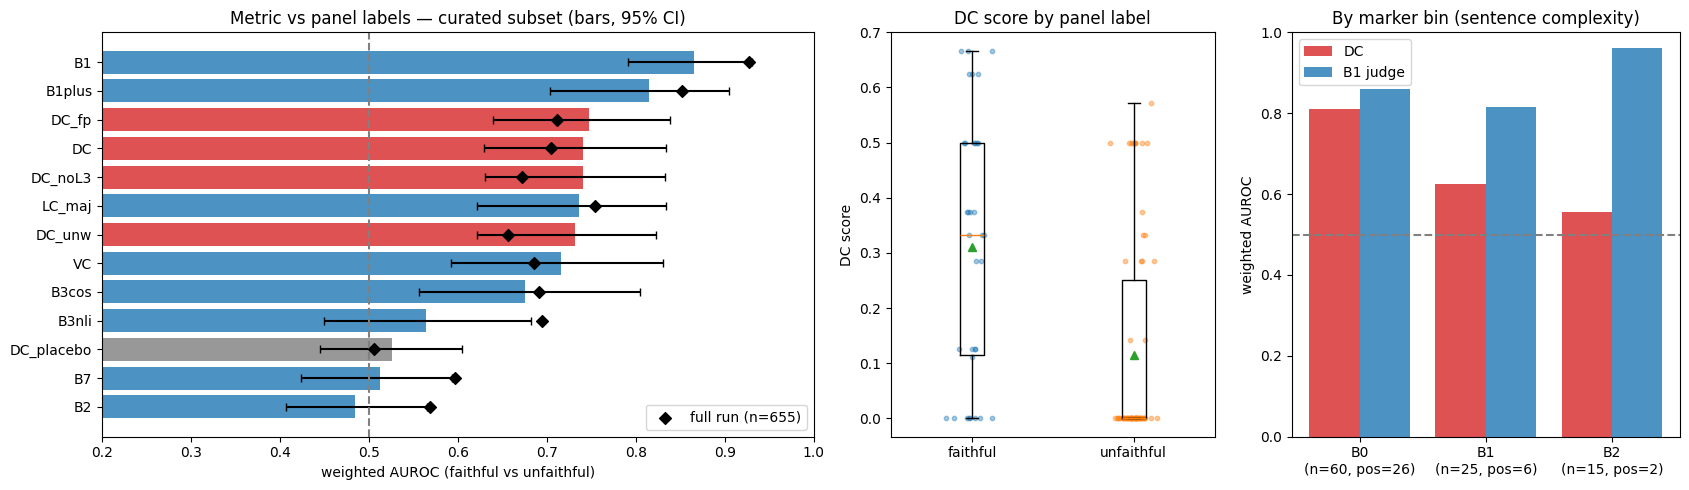

In [14]:
ref = data["reference"]
print(f"Full run  X1: AUROC(DC) = {ref['X1']['auroc_w']:.3f}  CI95 {np.round(ref['X1']['ci95'], 3).tolist()}  "
      f"(n={ref['X1']['n']}, pass={ref['X1']['pass']})")
print(f"Full run  X2: dAUROC([B1,parse,DC] - [B1,parse]) = {ref['X2']['delta']:+.3f}  CI95 {np.round(ref['X2']['ci95'], 3).tolist()}  "
      f"(pass={ref['X2']['pass']})")
dc_row = res.set_index("metric").loc["DC"]
print(f"Subset      : AUROC(DC) = {dc_row['AUROC_subset']:.3f}  CI95 [{dc_row['ci_lo']:.3f}, {dc_row['ci_hi']:.3f}]  (n={len(ex)})")
print(f"Live re-run : {int(live['match'].sum())}/{len(live)} candidates reproduce the frozen DC score exactly\n")

fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [2.2, 1, 1.2]})
r_sorted = res.sort_values("AUROC_subset")
yy = np.arange(len(r_sorted))
colors = ["#d62728" if m.startswith("DC") and m != "DC_placebo" else "#7f7f7f" if m == "DC_placebo" else "#1f77b4"
          for m in r_sorted["metric"]]
axes[0].barh(yy, r_sorted["AUROC_subset"], color=colors, alpha=0.8,
             xerr=[r_sorted["AUROC_subset"] - r_sorted["ci_lo"], r_sorted["ci_hi"] - r_sorted["AUROC_subset"]], capsize=3)
axes[0].scatter(r_sorted["AUROC_full_run"], yy, marker="D", color="black", zorder=3, label="full run (n=655)")
axes[0].axvline(0.5, ls="--", color="grey")
axes[0].set_yticks(yy, r_sorted["metric"])
axes[0].set_xlim(0.2, 1.0)
axes[0].set_xlabel("weighted AUROC (faithful vs unfaithful)")
axes[0].set_title("Metric vs panel labels — curated subset (bars, 95% CI)")
axes[0].legend(loc="lower right")

dc = col("DC")
axes[1].boxplot([dc[y == 1], dc[y == 0]], showmeans=True)
axes[1].set_xticks([1, 2], ["faithful", "unfaithful"])
for k, grp in enumerate([dc[y == 1], dc[y == 0]], 1):
    axes[1].scatter(np.random.default_rng(k).normal(k, 0.06, len(grp)), grp, s=10, alpha=0.4)
axes[1].set_ylabel("DC score")
axes[1].set_title("DC score by panel label")

xb = np.arange(len(by_bin))
axes[2].bar(xb - 0.2, by_bin["DC"], 0.4, label="DC", color="#d62728", alpha=0.8)
axes[2].bar(xb + 0.2, by_bin["B1"], 0.4, label="B1 judge", color="#1f77b4", alpha=0.8)
axes[2].axhline(0.5, ls="--", color="grey")
axes[2].set_xticks(xb, [f"{b}\n(n={n}, pos={p})" for b, n, p in zip(by_bin["bin"], by_bin["n"], by_bin["n_faithful"])])
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("weighted AUROC")
axes[2].set_title("By marker bin (sentence complexity)")
axes[2].legend()
plt.tight_layout()
plt.show()